# The Munthe-Kaas–Wright (MKW) Hopf Algebra

This notebook demonstrates the **Munthe-Kaas–Wright (MKW) Hopf algebra**
as implemented in the `kauri` package.

The MKW Hopf algebra is defined on **planar (ordered) rooted trees**
and uses the **shuffle product** as its multiplication. Unlike the NCK
Hopf algebra (which uses noncommutative forest concatenation), the MKW
shuffle product is **commutative**, making the MKW algebra a commutative
but non-cocommutative Hopf algebra.

The **coproduct** is defined via **left-admissible cuts**, a restriction
of the NCK admissible cuts where edges cut from the same vertex must
form a left prefix of the children at that vertex.

This algebra is the correct algebraic framework for the analysis of
**Lie–Butcher series**, which generalize B-series to Lie group
integrators and differential equations on manifolds.

**Reference:**

> H. Munthe-Kaas and W. Wright, *On the Hopf algebraic structure of
> Lie group integrators*, Foundations of Computational Mathematics
> **8** (2008), 227–257. arXiv: [math/0603023](https://arxiv.org/abs/math/0603023).

In [35]:
import kauri as kr
import kauri.mkw as mkw
import kauri.nck as nck

PT = kr.PlanarTree

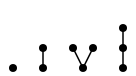

In [36]:
# Define the basic planar trees we will use throughout
bullet = PT([])          # order 1: single node
chain2 = PT([[]])        # order 2: chain of length 2
cherry = PT([[], []])    # order 3: cherry (Y-shape)
chain3 = PT([[[]]])      # order 3: chain of length 3

kr.display(bullet, chain2, cherry, chain3)

## 1. Shuffle product

The multiplication in the MKW Hopf algebra is the **shuffle product**
of ordered forests. Given two ordered forests $F = (t_1, \ldots, t_m)$
and $G = (s_1, \ldots, s_n)$, their shuffle product
$F \, ⧢ \, G$ is the sum of all interleavings of $F$ and $G$ that
preserve the relative order within each forest. There are
$\binom{m+n}{m}$ such interleavings.

The shuffle product is commutative and associative.

Verified against Munthe-Kaas & Wright (2008), Table 2, arXiv math/0603023.

### Examples from Table 2

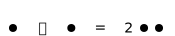

In [37]:
from kauri.trees import OrderedForest

# shuffle(bullet, bullet) = 2*(bullet,bullet)
# There are C(2,1) = 2 interleavings of (bullet) and (bullet), both give (bullet,bullet)
kr.display(bullet, "⧢", bullet, "=", mkw.shuffle_product(bullet, bullet))

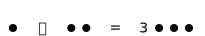

In [38]:
# shuffle(bullet, (bullet,bullet)) = 3*(bullet,bullet,bullet)
# C(3,1) = 3 interleavings, all produce (bullet,bullet,bullet)
f_bb = OrderedForest((bullet, bullet))
kr.display(bullet, "⧢", f_bb, "=", mkw.shuffle_product(bullet, f_bb))

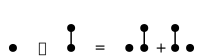

In [39]:
# shuffle(bullet, chain2) = (bullet,chain2) + (chain2,bullet)
# Two distinct interleavings since the trees are different
kr.display(bullet, "⧢", chain2, "=", mkw.shuffle_product(bullet, chain2))

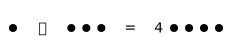

In [40]:
# shuffle(bullet, (bullet,bullet,bullet)) = 4*(bullet,bullet,bullet,bullet)
f_bbb = OrderedForest((bullet, bullet, bullet))
kr.display(bullet, "⧢", f_bbb, "=", mkw.shuffle_product(bullet, f_bbb))

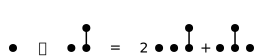

In [41]:
# shuffle(bullet, (bullet,chain2)) = 2*(bullet,bullet,chain2) + (bullet,chain2,bullet)
# Note: bullet-first gives 2 positions since two bullets are identical
f_bc = OrderedForest((bullet, chain2))
kr.display(bullet, "⧢", f_bc, "=", mkw.shuffle_product(bullet, f_bc))

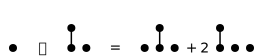

In [42]:
# shuffle(bullet, (chain2,bullet)) = 2*(chain2,bullet,bullet) + (bullet,chain2,bullet)
f_cb = OrderedForest((chain2, bullet))
kr.display(bullet, "⧢", f_cb, "=", mkw.shuffle_product(bullet, f_cb))

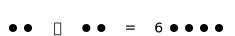

In [43]:
# shuffle((bullet,bullet), (bullet,bullet)) = 6*(bullet,bullet,bullet,bullet)
# C(4,2) = 6, all produce (bullet,bullet,bullet,bullet)
kr.display(f_bb, "⧢", f_bb, "=", mkw.shuffle_product(f_bb, f_bb))

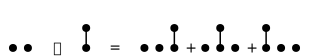

In [44]:
# shuffle((bullet,bullet), chain2) = (bullet,bullet,chain2) + (bullet,chain2,bullet) + (chain2,bullet,bullet)
kr.display(f_bb, "⧢", chain2, "=", mkw.shuffle_product(f_bb, chain2))

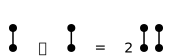

In [45]:
# shuffle(chain2, chain2) = 2*(chain2,chain2)
# Both orderings give (chain2,chain2)
kr.display(chain2, "⧢", chain2, "=", mkw.shuffle_product(chain2, chain2))

### Commutativity

The shuffle product is commutative: $F \, ⧢ \, G = G \, ⧢ \, F$.

In [46]:
lhs = mkw.shuffle_product(f_bb, chain2)
rhs = mkw.shuffle_product(chain2, f_bb)
print("shuffle((b,b), chain2) == shuffle(chain2, (b,b))?", lhs == rhs)

shuffle((b,b), chain2) == shuffle(chain2, (b,b))? True


In [47]:
lhs = mkw.shuffle_product(f_bc, chain2)
rhs = mkw.shuffle_product(chain2, f_bc)
print("shuffle((b,chain2), chain2) == shuffle(chain2, (b,chain2))?", lhs == rhs)

shuffle((b,chain2), chain2) == shuffle(chain2, (b,chain2))? True


### Associativity

The shuffle product is associative:
$(F \, ⧢ \, G) \, ⧢ \, H = F \, ⧢ \, (G \, ⧢ \, H)$.

Since the result of a shuffle is a `ForestSum`, we use the internal
bilinear extension `_shuffle_forestsums` to compose shuffle products.

In [48]:
from kauri.mkw.mkw import _shuffle_forestsums, _shuffle_forestsum_with_forest

F = OrderedForest((bullet,))
G = OrderedForest((chain2,))
H = OrderedForest((bullet, bullet))

# (F shuffle G) shuffle H
fg = mkw.shuffle_product(F, G)
lhs = _shuffle_forestsum_with_forest(fg, H)

# F shuffle (G shuffle H)
gh = mkw.shuffle_product(G, H)
rhs = _shuffle_forestsum_with_forest(gh, F)

print("(F shuffle G) shuffle H == F shuffle (G shuffle H)?", lhs == rhs)

(F shuffle G) shuffle H == F shuffle (G shuffle H)? True


## 2. Coproduct

The MKW coproduct $\Delta_{\mathrm{MKW}}$ is defined via
**left-admissible cuts**. An admissible cut $c$ of a tree
$t = B_+(t_1, \ldots, t_k)$ is **left-admissible** if, for any vertex,
the edges cut at that vertex form a **left prefix** of the children
at that vertex.

This means that at any given vertex with children $(t_1, \ldots, t_k)$,
one may only prune a contiguous block of the leftmost children
$t_1, \ldots, t_m$ (for some $0 \le m \le k$), while deeper cuts
within $t_{m+1}, \ldots, t_k$ are still allowed.

Pruned sub-forests from different vertices are combined using the
**shuffle product** (not concatenation as in NCK).

Verified against Munthe-Kaas & Wright (2008), Table 5, arXiv math/0603023.

### Basic examples

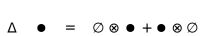

In [49]:
kr.display("Δ", bullet, "=", mkw.coproduct(bullet))

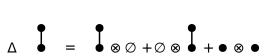

In [50]:
kr.display("Δ", chain2, "=", mkw.coproduct(chain2))

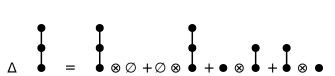

In [51]:
kr.display("Δ", chain3, "=", mkw.coproduct(chain3))

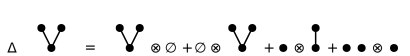

In [52]:
# NOTE: only 1*bullet (x) chain2 (not 2*bullet (x) chain2 as in NCK).
# This is because only the LEFT child edge can be cut alone
# (left-admissible constraint). Cutting the right child alone is
# not left-admissible.
kr.display("Δ", cherry, "=", mkw.coproduct(cherry))

### Comparison with NCK coproduct

For the cherry tree $Y = B_+(\bullet, \bullet)$, the key difference
between MKW and NCK is:

- **MKW:** $1 \cdot \bullet \otimes B_+(\bullet)$ &mdash; only the left child can be cut alone
- **NCK:** $2 \cdot \bullet \otimes B_+(\bullet)$ &mdash; either child can be cut

For **chain (ladder) trees**, where every node has at most one child,
the MKW and NCK coproducts coincide.

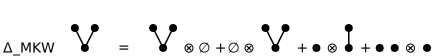

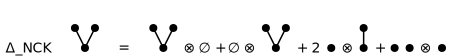

In [53]:
kr.display("Δ_MKW", cherry, "=", mkw.coproduct(cherry))
kr.display("Δ_NCK", cherry, "=", nck.coproduct(cherry))

In [54]:
# For chain trees, MKW = NCK
print("MKW == NCK for chain2?", mkw.coproduct(chain2) == nck.coproduct(chain2))
print("MKW == NCK for chain3?", mkw.coproduct(chain3) == nck.coproduct(chain3))

MKW == NCK for chain2? True
MKW == NCK for chain3? True


### Order 4 examples

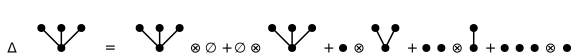

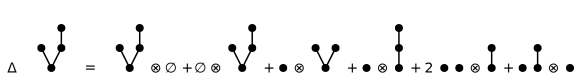

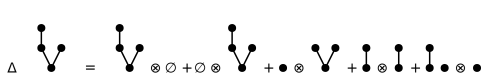

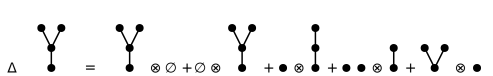

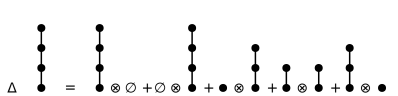

In [55]:
for t in kr.planar_trees_of_order(4):
    kr.display("Δ", t, "=", mkw.coproduct(t))
    print()

## 3. Antipode

The MKW antipode $S_{\mathrm{MKW}}$ is defined recursively by
$S(\emptyset) = \emptyset$, $S(\bullet) = -\bullet$, and for a tree
$t$ with coproduct $\Delta(t) = t \otimes \emptyset + \sum c_i\, L_i \otimes R_i$:

$$S(t) = -t - \sum c_i\, S(L_i) \, ⧢ \, R_i$$

Because the MKW algebra is **commutative** (the shuffle product is
commutative), the antipode is a **homomorphism**:
$S(F_1 \, ⧢ \, F_2) = S(F_1) \, ⧢ \, S(F_2)$.
This is in contrast to the NCK antipode, which is an anti-homomorphism.

Verified against Munthe-Kaas & Wright (2008), Table 6, arXiv math/0603023.

### Tree antipode

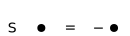

In [56]:
kr.display("S", bullet, "=", mkw.antipode(bullet))

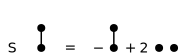

In [57]:
kr.display("S", chain2, "=", mkw.antipode(chain2))

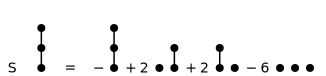

In [58]:
kr.display("S", chain3, "=", mkw.antipode(chain3))

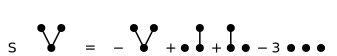

In [59]:
kr.display("S", cherry, "=", mkw.antipode(cherry))

### Forest antipode

The MKW antipode on forests uses a **forest-level recursion**, not
tree-by-tree application. For single-tree forests it reduces to the
tree antipode, but for multi-tree forests the formula involves the
coproduct of the tree $B_+(\omega)$ formed by grafting all trees
in the forest onto a common root.

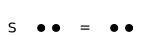

In [60]:
from kauri.mkw.mkw import _forest_antipode

# S(bullet, bullet) = (bullet, bullet)
f_bb = OrderedForest((bullet, bullet))
kr.display("S", f_bb, "=", _forest_antipode(f_bb))

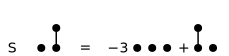

In [61]:
# S(bullet, chain2) = (chain2, bullet) - 3*(bullet, bullet, bullet)
f_bc = OrderedForest((bullet, chain2))
kr.display("S", f_bc, "=", _forest_antipode(f_bc))

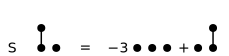

In [62]:
# S(chain2, bullet) = (bullet, chain2) - 3*(bullet, bullet, bullet)
f_cb = OrderedForest((chain2, bullet))
kr.display("S", f_cb, "=", _forest_antipode(f_cb))

## 4. Hopf algebra axioms

### Counit

The counit satisfies $\varepsilon(\emptyset) = 1$ and
$\varepsilon(t) = 0$ for all non-empty trees $t$.

In [63]:
print("counit(empty) =", mkw.counit(PT(None)))
print("counit(bullet) =", mkw.counit(bullet))
print("counit(chain2) =", mkw.counit(chain2))
print("counit(cherry) =", mkw.counit(cherry))

counit(empty) = 1
counit(bullet) = 0
counit(chain2) = 0
counit(cherry) = 0


### Antipode axiom: $\mu_{⧢} \circ (S \otimes \mathrm{id}) \circ \Delta = \eta \circ \varepsilon$

For every non-empty tree $t$, we verify that
$\sum c_i\, S(L_i) \, ⧢ \, R_i = 0$
where $\Delta(t) = \sum c_i\, L_i \otimes R_i$.

This uses the forest-level antipode `_forest_antipode` and the
shuffle product to recombine the left and right tensor factors.

In [64]:
from kauri.trees import ForestSum

def verify_antipode_axiom(t):
    """Check mu_shuffle o (S tensor id) o Delta(t) == counit(t)."""
    cp = mkw.coproduct(t)
    result = ForestSum(())
    for c, left_forest, right_forest in cp:
        s_left = _forest_antipode(left_forest)
        shuffled = _shuffle_forestsum_with_forest(s_left, right_forest)
        result = result + c * shuffled
    return result.simplify()

all_ok = True
for t in kr.planar_trees_up_to_order(4):
    if t.list_repr is None:
        continue
    result = verify_antipode_axiom(t)
    is_zero = len(result.term_list) == 0 or all(c == 0 for c, _ in result.term_list)
    if not is_zero:
        print(f"FAIL at {t}: {result}")
        all_ok = False

print("Antipode axiom holds for all planar trees up to order 4:", all_ok)

Antipode axiom holds for all planar trees up to order 4: True


### Coassociativity via convolution associativity

Coassociativity of $\Delta$ is equivalent to associativity of the
convolution product. We verify that for scalar-valued maps $f, g, h$:

$$(f \cdot g) \cdot h = f \cdot (g \cdot h)$$

holds for all planar trees up to order 4.

In [65]:
from math import isclose

f = kr.Map(lambda t: 1 if t.list_repr is None else 1 / t.factorial())
g = kr.Map(lambda t: 1 if t.list_repr is None else t.nodes())
h = kr.Map(lambda t: 1 if t.list_repr is None else (-1) ** t.nodes())

fg_h = mkw.map_product(mkw.map_product(f, g), h)   # (f*g)*h
f_gh = mkw.map_product(f, mkw.map_product(g, h))   # f*(g*h)

result = True
for t in kr.planar_trees_up_to_order(4):
    if not isclose(fg_h(t), f_gh(t), abs_tol=1e-12):
        result = False
        break

print("Convolution associativity (implies coassociativity):", result)

Convolution associativity (implies coassociativity): True


## 5. Application: Lie–Butcher series

The MKW Hopf algebra provides the algebraic foundation for
**Lie–Butcher series** (LB-series), which generalize classical
B-series to differential equations on **Lie groups** and
**homogeneous manifolds**.

The key differences from the classical (BCK) setting are:

| Concept | BCK (B-series) | MKW (Lie–Butcher series) |
|---------|---------------|------------------------|
| Trees | Non-planar (unordered) | Planar (ordered) |
| Forest product | Commutative concatenation | Shuffle product |
| Coproduct | All admissible cuts | Left-admissible cuts only |
| Series indexed by | Rooted trees | Ordered forests |
| Target space | Vector space | Lie group / manifold |

In the LB-series framework:
- The **shuffle product** corresponds to the product structure in
  the universal enveloping algebra of free Lie algebras.
- The **left-admissible cut** coproduct encodes the composition of
  Lie group integrators.
- The **antipode** provides the inverse of a Lie–Butcher series,
  needed for computing backward error analysis on manifolds.

For further details, see:

> H. Munthe-Kaas and W. Wright, *On the Hopf algebraic structure of
> Lie group integrators*, Found. Comput. Math. **8** (2008), 227–257.

## 6. Convolution product

The convolution product of two scalar-valued maps $f, g$ in the MKW
Hopf algebra is

$$(f \cdot g)(t) = \mu_{⧢} \circ (f \otimes g) \circ \Delta_{\mathrm{MKW}}(t)$$

where $\mu_{⧢}$ is the shuffle product.

For **scalar-valued maps**, the MKW and NCK convolution products give
**identical results**. This is because when both $f$ and $g$ return
scalars, the shuffle coefficients in $\Delta_{\mathrm{MKW}}$ exactly
compensate for the difference between shuffle and concatenation
products in the scalar evaluation.

**Note:** `mkw.map_product` and `mkw.map_power` are designed for
**scalar-valued maps only**.

### MKW and NCK scalar convolutions agree

In [66]:
f = kr.Map(lambda t: 1 if t.list_repr is None else 1 / t.factorial())
g = kr.Map(lambda t: 1 if t.list_repr is None else t.nodes())

mkw_prod = mkw.map_product(f, g)
nck_prod = nck.map_product(f, g)

all_ok = True
for t in kr.planar_trees_up_to_order(4):
    if not isclose(mkw_prod(t), nck_prod(t), abs_tol=1e-12):
        print(f"DIFFER at {t}: mkw={mkw_prod(t)}, nck={nck_prod(t)}")
        all_ok = False

print("MKW and NCK scalar convolutions agree up to order 4:", all_ok)

MKW and NCK scalar convolutions agree up to order 4: True


### Convolution inverse: $f^{-1} \cdot f = \varepsilon$

In [67]:
f = kr.Map(lambda t: 1 if t.list_repr is None else 1 / t.factorial())
f_inv = mkw.map_power(f, -1)
f_inv_times_f = mkw.map_product(f_inv, f)

all_ok = True
for t in kr.planar_trees_up_to_order(4):
    val = f_inv_times_f(t)
    expected = mkw.counit(t)
    if not isclose(val, expected, abs_tol=1e-12):
        print(f"FAIL at {t}: got {val}, expected {expected}")
        all_ok = False

print("f^(-1) * f = counit:", all_ok)

f^(-1) * f = counit: True


### Convolution powers

In [68]:
f = kr.Map(lambda t: 1 if t.list_repr is None else 1 / t.nodes())

# Verify map_power(f, 3) == map_product(map_product(f, f), f)
f_cubed_power = mkw.map_power(f, 3)
f_cubed_product = mkw.map_product(mkw.map_product(f, f), f)

all_ok = True
for t in kr.planar_trees_up_to_order(4):
    if not isclose(f_cubed_power(t), f_cubed_product(t), abs_tol=1e-12):
        all_ok = False
        break

print("map_power(f, 3) == map_product(map_product(f, f), f):", all_ok)

map_power(f, 3) == map_product(map_product(f, f), f): True
